## 1. Project Overview

- **Predicts**: Student final grade (A, B, C, D, F)
- **Features used**: `weekly_self_study_hours`, `attendance_percentage`, `class_participation`
- `total_score` excluded: causes target leakage (grade is derived from it)
- `student_id` excluded: identifier, not predictive

## 2. Import Libraries

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
sns.set_style("whitegrid")

## 3. Load Raw Dataset

In [17]:
raw_path = "../student_performance.csv"
df_raw = pd.read_csv(raw_path)

print("Shape:", df_raw.shape)
print("\nFirst 5 rows:")
df_raw.head()
print("\nColumn names:")
print(df_raw.columns.tolist())
print("\nData types:")
df_raw.dtypes

Shape: (1000000, 6)

First 5 rows:

Column names:
['student_id', 'weekly_self_study_hours', 'attendance_percentage', 'class_participation', 'total_score', 'grade']

Data types:


student_id                   int64
weekly_self_study_hours    float64
attendance_percentage      float64
class_participation        float64
total_score                float64
grade                       object
dtype: object

## 4. Dataset Inspection

In [18]:
print("Shape:", df_raw.shape)
print("\nData types:")
df_raw.dtypes
print("\nMissing values:")
print(df_raw.isnull().sum())
print("\nDuplicate rows:", df_raw.duplicated().sum())
print("Duplicate student_id:", df_raw["student_id"].duplicated().sum())
print("\nUnique grades:", sorted(df_raw["grade"].unique()))
print("\nGrade distribution:")
df_raw["grade"].value_counts()

Shape: (1000000, 6)

Data types:

Missing values:
student_id                 0
weekly_self_study_hours    0
attendance_percentage      0
class_participation        0
total_score                0
grade                      0
dtype: int64

Duplicate rows: 0
Duplicate student_id: 0

Unique grades: ['A', 'B', 'C', 'D', 'F']

Grade distribution:


grade
A    548644
B    258174
C    141980
D     44998
F      6204
Name: count, dtype: int64

In [19]:
df_raw.describe()

,student_id,weekly_self_study_hours,attendance_percentage,class_participation,total_score
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000
mean,500000.500000,15.029127,84.711046,5.985203,84.283845
std,288675.278932,6.899431,9.424143,1.956421,15.432969
min,1.000000,0.000000,50.000000,0.000000,9.400000
25%,250000.750000,10.300000,78.300000,4.700000,73.900000
50%,500000.500000,15.000000,85.000000,6.000000,87.500000
75%,750000.250000,19.700000,91.800000,7.300000,100.000000
max,1000000.000000,40.000000,100.000000,10.000000,100.000000


## 5. Data Validation

In [20]:
print("Validating documented ranges:")
print("\n1. weekly_self_study_hours (0-40):")
invalid_study = df_raw[(df_raw["weekly_self_study_hours"] < 0) | (df_raw["weekly_self_study_hours"] > 40)]
print(f"   Invalid rows: {len(invalid_study)}")

print("\n2. attendance_percentage (50-100):")
invalid_attendance = df_raw[(df_raw["attendance_percentage"] < 50) | (df_raw["attendance_percentage"] > 100)]
print(f"   Invalid rows: {len(invalid_attendance)}")

print("\n3. class_participation (0-10):")
invalid_participation = df_raw[(df_raw["class_participation"] < 0) | (df_raw["class_participation"] > 10)]
print(f"   Invalid rows: {len(invalid_participation)}")

print("\n4. total_score (0-100):")
invalid_score = df_raw[(df_raw["total_score"] < 0) | (df_raw["total_score"] > 100)]
print(f"   Invalid rows: {len(invalid_score)}")

Validating documented ranges:

1. weekly_self_study_hours (0-40):
   Invalid rows: 0

2. attendance_percentage (50-100):
   Invalid rows: 0

3. class_participation (0-10):
   Invalid rows: 0

4. total_score (0-100):
   Invalid rows: 0


## 6. Basic EDA

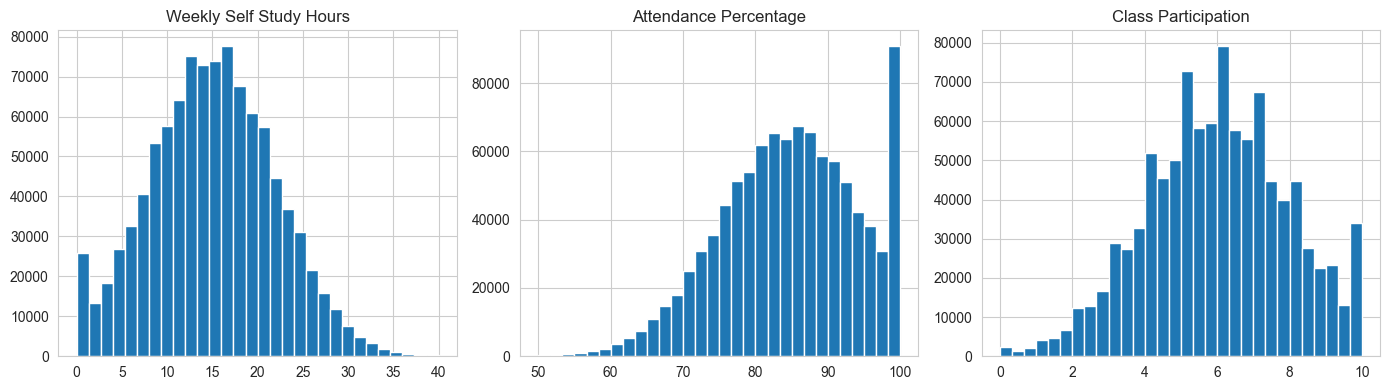

In [21]:
feature_cols = ["weekly_self_study_hours", "attendance_percentage", "class_participation"]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
df_raw["weekly_self_study_hours"].hist(ax=axes[0], bins=30)
axes[0].set_title("Weekly Self Study Hours")
df_raw["attendance_percentage"].hist(ax=axes[1], bins=30)
axes[1].set_title("Attendance Percentage")
df_raw["class_participation"].hist(ax=axes[2], bins=30)
axes[2].set_title("Class Participation")

plt.tight_layout()
plt.show()

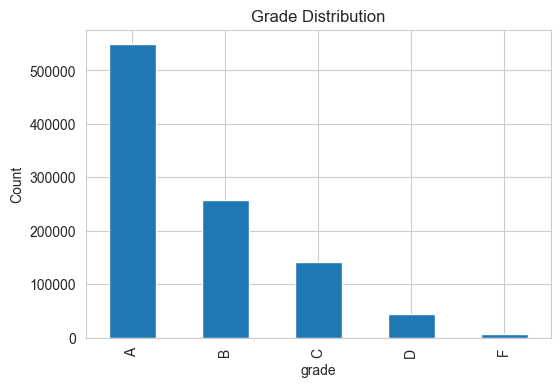

In [22]:
plt.figure(figsize=(6, 4))
df_raw["grade"].value_counts().sort_index().plot(kind="bar")
plt.title("Grade Distribution")
plt.ylabel("Count")
plt.show()

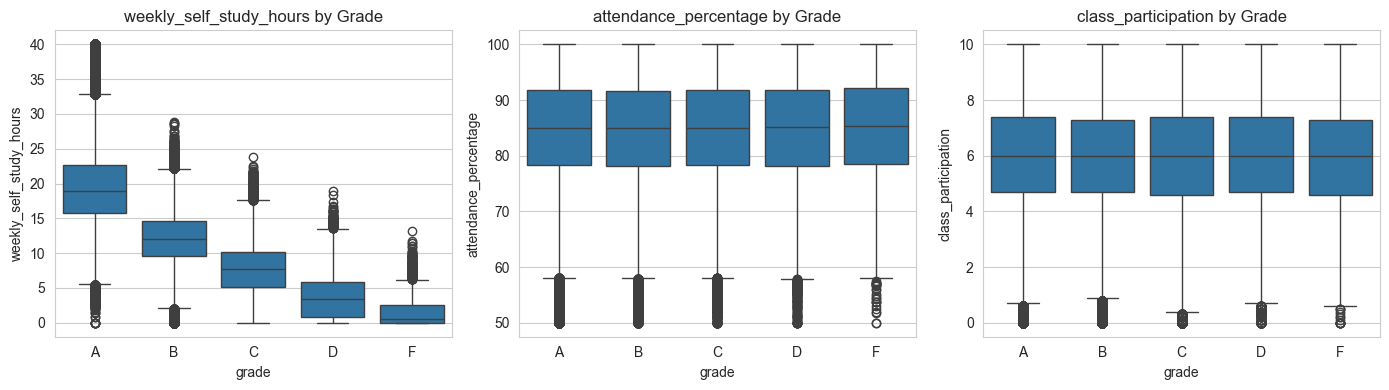

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for i, col in enumerate(feature_cols):
    sns.boxplot(x="grade", y=col, data=df_raw, ax=axes[i])
    axes[i].set_title(f"{col} by Grade")
plt.tight_layout()
plt.show()

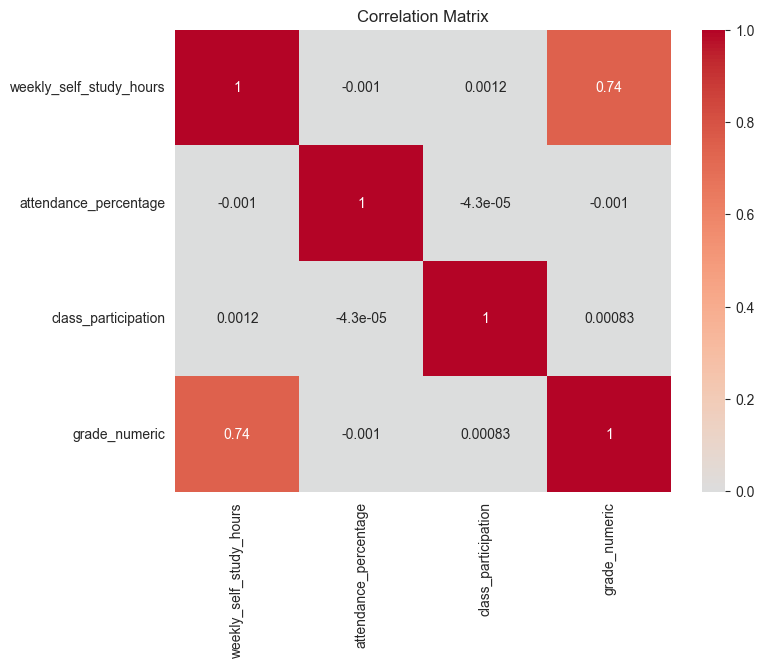

In [24]:
numeric_map = {"A": 4, "B": 3, "C": 2, "D": 1, "F": 0}
df_corr = df_raw.copy()
df_corr["grade_numeric"] = df_corr["grade"].map(numeric_map)

plt.figure(figsize=(8, 6))
sns.heatmap(df_corr[feature_cols + ["grade_numeric"]].corr(), annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Matrix")
plt.show()

## 7. Data Cleaning

In [25]:
df_clean = df_raw.copy()
original_rows = len(df_clean)

duplicates = df_clean.duplicated().sum()
if duplicates > 0:
    df_clean = df_clean.drop_duplicates()

required_cols = feature_cols + ["grade"]
df_clean = df_clean.dropna(subset=required_cols)

rows_removed = original_rows - len(df_clean)
print(f"Rows removed during cleaning: {rows_removed}")
print(f"Cleaned dataset shape: {df_clean.shape}")

Rows removed during cleaning: 0
Cleaned dataset shape: (1000000, 6)


## 8. Reduce Dataset Size

In [26]:
original_rows = len(df_clean)
target_samples = 50000

print("Grade distribution before sampling:")
dist_before = df_clean["grade"].value_counts().sort_index()
print(dist_before)

test_size_frac = 1 - (target_samples / original_rows)
df_sampled, _ = train_test_split(
    df_clean, test_size=test_size_frac, random_state=RANDOM_SEED, stratify=df_clean["grade"]
)
df_sampled = df_sampled.head(target_samples).reset_index(drop=True)

print(f"\nOriginal rows: {original_rows}")
print(f"Sampled rows: {len(df_sampled)}")
print("\nGrade distribution after sampling:")
dist_after = df_sampled["grade"].value_counts().sort_index()
print(dist_after)

Grade distribution before sampling:
grade
A    548644
B    258174
C    141980
D     44998
F      6204
Name: count, dtype: int64

Original rows: 1000000
Sampled rows: 50000

Grade distribution after sampling:
grade
A    27432
B    12909
C     7099
D     2250
F      310
Name: count, dtype: int64


## 9. Define Features and Target

In [27]:
X = df_sampled[feature_cols].copy()
y = df_sampled["grade"].copy()

print("Feature columns:")
print(X.columns.tolist())
print("\nTarget column:", y.name)
print("\nVerification:")
print("  student_id in X:", "student_id" in X.columns)
print("  total_score in X:", "total_score" in X.columns)
print("\nX shape:", X.shape)
print("y shape:", y.shape)

Feature columns:
['weekly_self_study_hours', 'attendance_percentage', 'class_participation']

Target column: grade

Verification:
  student_id in X: False
  total_score in X: False

X shape: (50000, 3)
y shape: (50000,)


## 10. Train/Test Split

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_SEED, stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

print("\nClass distribution in y_train:")
print(y_train.value_counts().sort_index())
print("\nClass distribution in y_test:")
print(y_test.value_counts().sort_index())

X_train shape: (40000, 3)
X_test shape: (10000, 3)
y_train shape: (40000,)
y_test shape: (10000,)

Class distribution in y_train:
grade
A    21946
B    10327
C     5679
D     1800
F      248
Name: count, dtype: int64

Class distribution in y_test:
grade
A    5486
B    2582
C    1420
D     450
F      62
Name: count, dtype: int64


## 11. Feature Preprocessing

All features are numerical and benefit from standardization for ML models.

In [29]:
preprocessing_pipeline = Pipeline([
    ("scaler", StandardScaler())
])

X_train_scaled = preprocessing_pipeline.fit_transform(X_train)
X_test_scaled = preprocessing_pipeline.transform(X_test)

print("Preprocessing pipeline:")
print("  - StandardScaler: fit on train, transform train and test")
print(f"\nX_train_scaled shape: {X_train_scaled.shape}")
print(f"X_test_scaled shape: {X_test_scaled.shape}")
print(f"\nX_train sample (after scaling):")
print(np.round(X_train_scaled[:3], 3))

Preprocessing pipeline:
  - StandardScaler: fit on train, transform train and test

X_train_scaled shape: (40000, 3)
X_test_scaled shape: (10000, 3)

X_train sample (after scaling):
[[ 0.853  1.23   0.974]
 [ 0.766 -0.274 -2.57 ]
 [-0.979 -0.677 -0.207]]


## 12. Final Modeling Dataset Summary

In [30]:
print("=== FINAL MODELING DATASET SUMMARY ===")
print(f"Final dataset size: {len(df_clean)} rows (sample: {len(df_sampled)})")
print(f"Feature columns: {X.columns.tolist()}")
print(f"Target column: {y.name}")
print(f"Train size: {X_train.shape[0]} samples")
print(f"Test size: {X_test.shape[0]} samples")
print(f"Missing values in features: {X.isnull().sum().sum()}")
print(f"Missing values in target: {y.isnull().sum()}")
print(f"Class distribution: {y.value_counts().sort_index().to_dict()}")
print("\nTarget leakage check:")
print("  - student_id NOT in features:", "student_id" not in X.columns)
print("  - total_score NOT in features:", "total_score" not in X.columns)
print("\nStratified split verified: train and test have similar grade distributions")

=== FINAL MODELING DATASET SUMMARY ===
Final dataset size: 1000000 rows (sample: 50000)
Feature columns: ['weekly_self_study_hours', 'attendance_percentage', 'class_participation']
Target column: grade
Train size: 40000 samples
Test size: 10000 samples
Missing values in features: 0
Missing values in target: 0
Class distribution: {'A': 27432, 'B': 12909, 'C': 7099, 'D': 2250, 'F': 310}

Target leakage check:
  - student_id NOT in features: True
  - total_score NOT in features: True

Stratified split verified: train and test have similar grade distributions
